# Coverage

This notebook shows how much of the state road network in the configured box has each of the four attributes, how much passes each filter, and where values are missing. The last section rebuilds one road part by hand and compares it with `network.py`.

Run `uv run roadcycling fetch` and `uv run roadcycling build` first.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from roadcycling import config, fetch, network, score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cfg = config.load(ROOT / "config.toml")
segs = gpd.read_file(ROOT / "data/processed/segments.gpkg", layer="segments")
BLUE = "#2a78d6"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#52514e",
        "axes.labelcolor": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
    }
)

## Attributes and filters

Lengths are carriageway kilometres. Carriageway 2 of divided roads is dropped, so a divided road counts once. A segment with a missing value fails that filter.

In [2]:
def km(mask):
    return segs.loc[mask, "length_m"].sum() / 1000


total = segs["length_m"].sum() / 1000
checks = {
    "speed limit": (segs.speed_limit.notna(), segs.speed_limit <= cfg.max_speed_limit),
    "traffic": (segs.kvl.notna(), segs.kvl <= cfg.max_kvl),
    "surface": (segs.surface.notna(), segs.surface.isin(cfg.surfaces)),
    "condition": (segs.condition.notna(), segs.condition >= cfg.min_condition),
}
table = pd.DataFrame(
    {
        name: {
            "km with value": km(has),
            "% with value": 100 * km(has) / total,
            "km passing": km(ok),
        }
        for name, (has, ok) in checks.items()
    }
).T
complete = segs["missing"].fillna("") == ""
table.loc["all four"] = [km(complete), 100 * km(complete) / total, km(segs.passes)]
print(f"{len(segs)} segments, {total:.0f} km of carriageway")
table.round(0)

95509 segments, 12321 km of carriageway


,km with value,% with value,km passing
speed limit,9799.0,80.0,8622.0
traffic,10061.0,82.0,6080.0
surface,11114.0,90.0,9170.0
condition,7410.0,60.0,6112.0
all four,7262.0,59.0,2862.0


## Wearing course types

`network.surface_class` turns each wearing course type into `asphalt`, `soft_asphalt` or nothing. The table lists every type with its length, so a type the mapping leaves out shows up with an empty `surface`. Only intervals inside one road part are counted, since their length is the difference of two distances.

In [3]:
raw = fetch.load_raw(ROOT / "data/raw")
pav = pd.DataFrame([f["properties"] for f in raw["pavement"]["features"]])
pav = pav[(pav.tyyppi == "Kulutuskerros") & (pav.alkusijainti_osa == pav.loppusijainti_osa)]
pav["km"] = (pav.loppusijainti_etaisyys - pav.alkusijainti_etaisyys) / 1000
pav["surface"] = pav.paallysteen_tyyppi.map(network.surface_class)
pav.groupby(["paallysteen_tyyppi", "surface"], dropna=False)["km"].sum().sort_values(
    ascending=False
).round(1)

paallysteen_tyyppi                        surface     
Asfalttibetoni                            asphalt         7954.5
Kivimastiksiasfaltti                      asphalt         3173.3
Pehmeät asfalttibetonit (PAB-V)           soft_asphalt    3067.0
Pehmeät asfalttibetonit (PAB-B)           soft_asphalt    1500.8
Sidekerroksen asfalttibetoni (ABS)        asphalt           13.9
Kantavan kerroksen asfalttibetoni (ABK)   asphalt           12.9
Pehmeät asfalttibetonit (PAB-O)           soft_asphalt       3.9
Epäjatkuva asfaltti (Poistunut käytöstä)  NaN                1.6
Ei tietoa                                 NaN                0.8
Avoin asfaltti                            asphalt            0.3
Name: km, dtype: float64

## Where values are missing

Each segment is coloured by how many of the four attributes it lacks.

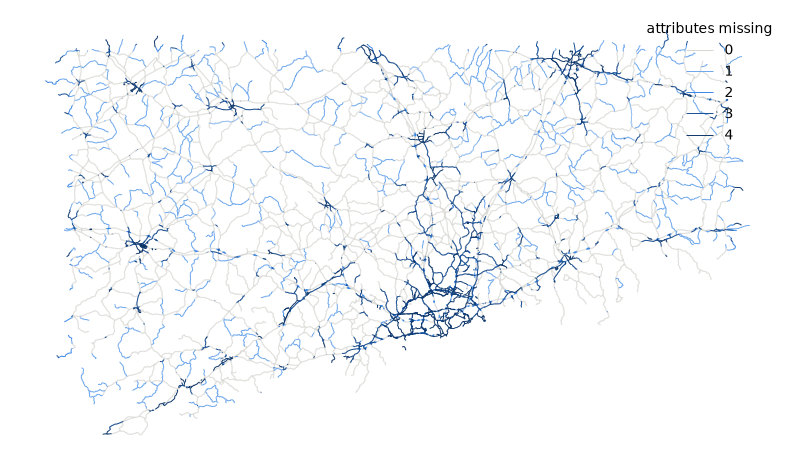

In [4]:
from matplotlib.colors import ListedColormap

segs["n_missing"] = segs["missing"].fillna("").map(lambda s: len([x for x in s.split(",") if x]))
cmap = ListedColormap(["#d6d5d0", "#6da7ec", "#3987e5", "#184f95", "#0d366b"])
fig, ax = plt.subplots(figsize=(10, 7))
segs.plot(
    ax=ax,
    column="n_missing",
    categorical=True,
    cmap=cmap,
    linewidth=0.7,
    legend=True,
    legend_kwds={"title": "attributes missing", "frameon": False},
)
ax.set_axis_off()

## One road part by hand

Road 11269 part 1 is a divided road from 0 to 1088 m and a single carriageway from 1088 to 5897 m. Its single-carriageway feature starts at address 1088, which is the case the cutting by M values exists for.

We list every interval that touches the part, cut the address range by hand at every interval end, take the worse value for each piece, and compare the result with the segments `network.py` built.

In [5]:
TIE, OSA = 11269, 1
tables = network.interval_tables(raw)
part = next(
    p
    for p in network.network_parts(raw["network"])
    if (p["tie"], p["osa"], p["ajorata"]) == (TIE, OSA, 0)
)
m0, m1 = network.m_range(part["lines"])
print("this feature covers addresses", m0, "to", m1)


def touching(name):
    t = tables[name]
    return t[(t.tie == TIE) & (t.aosa <= OSA) & (t.losa >= OSA)]


for name in tables:
    print(name)
    display(touching(name))

this feature covers addresses 1088.0 to 5897.0
speed


,tie,aosa,aet,losa,let,speed_limit
337,11269,1,2016,1,2844,40
338,11269,1,2016,1,2844,40
749,11269,1,795,1,1088,40
763,11269,1,1088,1,1333,40
769,11269,1,2844,1,5897,50
771,11269,1,2844,1,5897,50
883,11269,1,795,1,1333,40


traffic


,tie,aosa,aet,losa,let,kvl,kvl_year
2163,11269,1,2790,1,5897,1150.0,2025.0


surface


,tie,aosa,aet,losa,let,surface_rank,surface
804,11269,1,795,1,1088,0.0,asphalt
805,11269,1,795,1,1088,0.0,asphalt
853,11269,1,5836,1,5868,0.0,asphalt
854,11269,1,5836,1,5868,0.0,asphalt
855,11269,1,5868,1,5884,0.0,asphalt
856,11269,1,5868,1,5884,0.0,asphalt
857,11269,1,5884,1,5897,1.0,soft_asphalt
858,11269,1,5884,1,5897,1.0,soft_asphalt
2677,11269,1,1088,1,1288,0.0,asphalt
2678,11269,1,1088,1,1288,0.0,asphalt


condition


,tie,aosa,aet,losa,let,condition,iri,rut_mm
6007,11269,1,4600,1,4700,4,2.3,8.4
8263,11269,1,5300,1,5400,3,3.1,16.7
12742,11269,1,4900,1,5000,3,3.1,15.4
18822,11269,1,5400,1,5500,4,3.3,12.7
26470,11269,1,5700,1,5800,3,4.2,16.1
28773,11269,1,3200,1,3300,4,2.6,10.0
31830,11269,1,2800,1,2900,5,1.6,2.0
31831,11269,1,4700,1,4800,4,2.8,10.0
32572,11269,1,5000,1,5100,4,3.4,10.6
35648,11269,1,4300,1,4400,4,2.9,13.1


In [6]:
# cut points: every interval end that falls inside [m0, m1]
cuts = {m0, m1}
for name in tables:
    for _, r in touching(name).iterrows():
        start = r.aet if r.aosa == OSA else m0
        end = r["let"] if r.losa == OSA else m1
        cuts |= {min(max(start, m0), m1), min(max(end, m0), m1)}
cuts = sorted(cuts)

worst = {
    "speed": ("speed_limit", max),
    "traffic": ("kvl", max),
    "surface": ("surface_rank", max),
    "condition": ("condition", min),
}
by_hand = pd.DataFrame({"aet": cuts[:-1], "let": cuts[1:]})
for name, (col, pick) in worst.items():
    values = []
    for a, b in zip(cuts, cuts[1:]):
        mid = (a + b) / 2
        cover = [
            r[col]
            for _, r in touching(name).iterrows()
            if (r.aet if r.aosa == OSA else -1e9) <= mid < (r["let"] if r.losa == OSA else 1e9)
        ]
        values.append(pick(cover) if cover else np.nan)
    by_hand[col] = values

built = segs[(segs.tie == TIE) & (segs.osa == OSA) & (segs.ajorata == 0)].sort_values("aet")
built = built.assign(surface_rank=built.surface.map(network.SURFACE_RANK))
cols = ["aet", "let", "speed_limit", "kvl", "surface_rank", "condition"]
print("pieces by hand:", len(by_hand), " pieces built:", len(built))
diff = (
    by_hand[cols].astype(float).reset_index(drop=True)
    .compare(built[cols].astype(float).reset_index(drop=True))
)
print("differences:", len(diff))
by_hand

pieces by hand: 43  pieces built: 43
differences: 0


,aet,let,speed_limit,kvl,surface_rank,condition
0,1088.0,1288.0,40.0,NaN,0.0,NaN
1,1288.0,1333.0,40.0,NaN,0.0,NaN
2,1333.0,2016.0,NaN,NaN,NaN,NaN
3,2016.0,2790.0,40.0,NaN,0.0,NaN
4,2790.0,2800.0,40.0,1150.0,0.0,5.0
5,2800.0,2844.0,40.0,1150.0,0.0,5.0
6,2844.0,2900.0,50.0,1150.0,0.0,5.0
7,2900.0,3000.0,50.0,1150.0,0.0,5.0
8,3000.0,3005.0,50.0,1150.0,0.0,4.0
9,3005.0,3100.0,50.0,1150.0,0.0,4.0
